# Day 18 Pre-Class Assignment
---


### <p style="text-align: right;"> &#9989;&nbsp; Put your name here</p>

## Bootstrapping, the Central Limit Theorem, and confidence intervals

<img src="https://nulib.github.io/moderndive_book/images/garfield_comic.png" style="display:block; margin-left: auto; margin-right: auto; width: 65%" alt="If the weather forecast says that the temperature tomorrow will be between -100 and 100 degrees, technically it will always be correct.">
<p style="font-size:0.85em; text-align: center;">Credits: Jim Davis</p>

### Learning goals for today's pre-class assignment

* List the steps of a bootstrap procedure and relate its results to how confidence intervals are computed.
* State correctly the meaning of a 90%, a 95%, and a 99% confidence intervals.
* State correctly the meaning of the Central Limit Theorem and how it relates to the computation of confidence intervals via a formula.
* List the fine prints to consider when computing confidence intervals.

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

----

## 1. Confidence intervals via bootstrapping

So far we have worked means and standard errors of the mean. There is a related term that you might have heard of before: a confidence interval. The most common one is the "95% confidence interval". Just to be clear on definitions:

- **Standard error of the mean (SE):** The standard deviation of the means taken from multiple samples of the same population.
- **95% confidence interval (CI):** An interval than contains 95% of the means taken from multiple samples of the same population.

Just like with the standard error, the confidence interval depends upon multiple samples. And just like with the standard error, we can obtain quickly and cheaply a bunch of samples via bootstrapping. 

Watch the following video on what a confidence interval is and how it relates to bootstrapping.

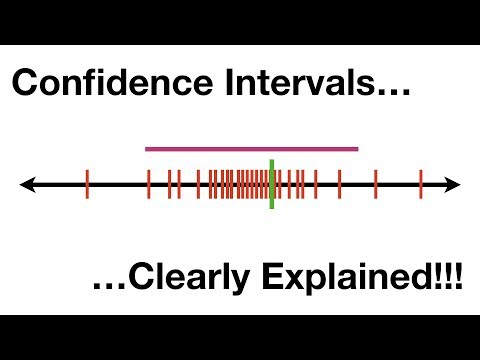

In [1]:
from IPython.display import YouTubeVideo  
YouTubeVideo("TqOeMYtOc1w",width=640,height=360)

&#9989;&nbsp; **Question 1** 

- In your own words, what is the difference between a 90%, a 95%, and a 99% confidence intervals?
- Is there a situation where we would prefer to work with 99% CIs instead of 95% CIs?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Question 2** 

As in the video, say you are weighing mice and you find that the 95% confidence interval for female mice weight is $21$ to $31$ grams. This sometimes is written as $(21,31)$.

Which of the following statements is true?

- The 100% confidence interval is $(0 , 1000000)$.
- The 100% confidence interval is $(0 , \infty)$.
- The 100% confidence interval is $(-\infty , \infty)$.
- All of the statements above are correct.
- None of the above. The actual 100% confidence interval is `_____<put your best guess/answer here>______`.

Explain your answer. How does this question relate to the Garfield joke at the beginning of the Notebook?

<font size=+3>&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Question 3** 

Still looking at mice, are the two following statements equivalent?

- There is a 95% chance that the $(21,31)$ interval contains the true mean weight of female mice.
- There is a 95% chance that the true mean weight of female mice falls in the $(21,31)$ interval.

Explain your answer. Hold on to that thought for the In-Class assignment.

<font size=+3>&#9998;</font> *Put your answer here.*


---

## 2. Rice weevils and bootstraps

Let's revisit the [Hetherington et al (2025)](https://doi.org/10.1002/ps.70230) data for consumed weevils by different natural predators in the `Natural Predator Data_combined.csv` file.

### 2.1 Revisiting our computations and a taste of `groupby`

First, we need to set-up everything:

In [2]:
# importing and loading

import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

# Load concentration values and replace every NaN with a zero
data = pd.read_csv('Natural Predator Data_combined.csv')
data.head()

,Year,Date,Order,Family,Rep,# of Weevils Remaining,Avg Weevils Consumed,Comments,Evaluator,NCE,Individual,Unnamed: 11,Unnamed: 12
0,2022,9/9/2022,Orthoptera,Acrididae,3,10,0,NCE,RM,1,1,NaN,NaN
1,2022,9/22/2022,Orthoptera,Acrididae,2,10,0,NCE,ARG,1,1,NaN,NaN
2,2022,9/22/2022,Orthoptera,Acrididae,4,9,10,NCE,ARG,1,1,NaN,NaN
3,2022,9/22/2022,Orthoptera,Acrididae,5,2,80,NCE,ARG,1,1,NaN,NaN
4,2022,10/4/2022,Orthoptera,Acrididae,10,9,10,"NCE, NE dead",IS/RM,1,1,NaN,NaN


Back in In-Class 17 you selected a family&mdash;like `family = 'Acrididae'` (grasshoppers)&mdash;, masked the dataframe, and then computed the mean and standard error of weevils consumed % for this one family. You could then write a loop to go through all 12 families studied and write a `summary` DataFrame. But there is an easier way.

Now that you are a bit more comfortable with pandas, you may want to get acquainted its [groupby functions to split, apply, and combine.](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html). 

With `groupby`, we can make a summary DataFrame in a single line.

In [3]:
# Apply a `groupby` function to the data dataframe
# - group the rows in the dataframe based on the Year and Family columns
# - then look at the Avg Weevils Consumed values
# - aggregate (.agg) those values by computing the mean and SE for each of the families

summary = data.groupby(['Year', 'Family'], as_index=False)['Avg Weevils Consumed'].agg(['mean', 'sem'])

# Display the first 5 rows
summary.head()

,Year,Family,mean,sem
0,2022,Acrididae,17.272727,5.742747
1,2022,Carabidae,36.666667,31.797973
2,2022,Chrysopidae,3.333333,3.333333
3,2022,Coreidae,2.000000,2.000000
4,2022,Gryllidae,29.583333,7.766501


&#9989;&nbsp; **Task 4** 

**This Task won't affect the rest of the Notebook. Don't spend too much time on it if you don't figure it out.**

- Edit the cell above so that `summary` also has columns with the standard deviation, minimum, and maximum values of weevil consumption for each of 12 families.
    - *Hint:* Remember that we can compute mean values in pandas with the `.mean` function. Which is why we have `'mean'` inside the `.agg` function now to compute the mean of each group.
    - *Hint:* Similarly, we compute SEs with the `.sem` function, so we have `'sem'` in the `.agg` to get SEs for each group.
    - *Hint:* What do you think you need to add inside `.agg` to get minimum, maximum, and SD?
 
- What happens if you change `as_index=False` to `as_index=True`?
- What happens if you change `Avg Weevils Consumed'` for a list of columns, like `[ 'Avg Weevils Consumed', 'NCE' ]`? (a list within a list)

<font size=+3>&#9998;</font> *Put your answers here.*

### 2.2 Confidence intervals via bootstraps

- Let's get a Series with experimente values for grasshoppers collected in 2022.
- Remember we can mask and use `.loc` to get those values in a single line.

In [4]:
# A Series with only the tissue-day-cannabinoid values I care for
year = 2022
family = 'Acrididae'

values = data.loc[ (data['Family'] == family) & (data['Year'] == year), 'Avg Weevils Consumed' ]
values

0      0
1      0
2     10
3     80
4     10
5     10
6     10
7     60
8     10
9     50
10     0
11    10
12     0
13     0
14    90
15    20
16     0
17    10
18     0
19     0
20    10
21     0
Name: Avg Weevils Consumed, dtype: int64

- Just like with the standard error, we can estimate the confidence interval via bootstrap.
- We copy/paste from Pre-Class 17 to compute an array of `N = 10` bootstrapped means.

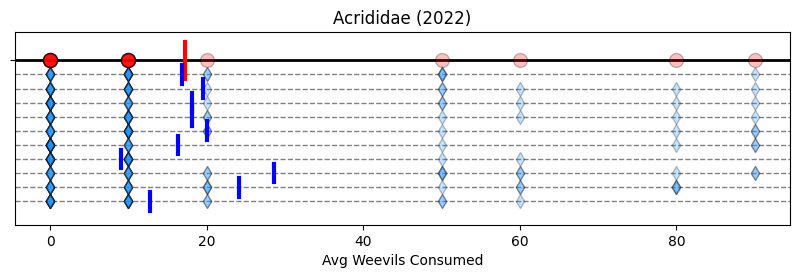

In [5]:
# Similar code as In-Class 17
# random number generator
rng = np.random.default_rng(seed = 42)

# Number of resamples for bootstrap
N = 10

# Plot code
fig, ax = plt.subplots(figsize=(10,2.5))
ax.set_ylim(-1.75, 0.3)
ax.set_yticks([0], '')
ax.set_title(f'{family} ({year})' )
ax.set_xlabel('Avg Weevils Consumed')
ax.axhline(0, c='k', lw=2, zorder=1)
ax.plot([values.mean(), values.mean()], [0.2, -0.2], c='r', lw=3, zorder=2)
ax.scatter(values , np.zeros(len(values)), alpha=0.25, marker='o', s=100, fc='r', ec = 'k', zorder=3);

means = np.zeros(N)
bootstrapped_samples = np.zeros((N,len(values)))

for i in range(N):
    sample = rng.choice(values, size = len(values), replace=True) # Resample allowing replacements
    bootstrapped_samples[i] = sample # Save the sample
    means[i] = sample.mean() # Save the mean of the resample
    
    nudge = -0.15*(i+1) # Every resample will be plotted a nudge below the previous one

    ax.axhline(nudge, c='gray', ls='dashed', lw=1, zorder=1)
    ax.scatter(sample , nudge+np.zeros(len(sample)), marker='d', alpha=0.25, s=50, fc='dodgerblue', ec = 'k', zorder=2)
    ax.plot([means[i], means[i]], [nudge+0.1, nudge-0.1], c='blue', lw=3, zorder=3)

Then for the 95% confidence interval, we look at the "central 95%"&mdash;we shave the bottom and top 2.5%, and keep the rest&mdash;like in the cartoon below. In other words, we look at the 2.5th and 97.5th *quantiles* of the `means` array. (We will discuss more about quantiles next week).

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20201028221445/CIDiagram.png" style="display:block; margin-left: auto; margin-right: auto; width: 50%" alt="Normal-like distribution function. The first and last 2.5% of it has been shaved off leaving only the 95% at center: the 95% confidence">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://www.geeksforgeeks.org/maths/confidence-intervals-for-population-mean-and-proportion/" target="_blank">geeksforgeeks.com</a></p>


**Important**: You'll find in some literature that the 95% confidence interval is referred to as the $\alpha = 0.95$ confidence level. By the same logic, 99% confidence interval corresponds to $\alpha = 0.99$ and 90% CI to $\alpha = 0.90$.

Notice that the lower and upper limits correspond to:
$$\text{Lower quantile} = \frac{1-\alpha}2,\quad\text{Upper quantile} = \frac{1+\alpha}2.$$

In [6]:
# Computing lower CI and upper CI quantiles
alpha = 0.95
lower_q = (1 - alpha)/2
upper_q = (1 + alpha)/2
print(f'Lower {(alpha)*100:.0f}% CI quantile:\t {lower_q:.3f}')
print(f'Upper {(alpha)*100:.0f}% CI quantile:\t {upper_q:.3f}')

Lower 95% CI quantile:	 0.025
Upper 95% CI quantile:	 0.975


And compute those quantiles to the array of means:

In [7]:
# Computing the actual quantile values of the bootstrapped means
# https://numpy.org/doc/stable/reference/generated/numpy.quantile.html

lower_ci, upper_ci = np.quantile(means, [lower_q, upper_q])

print(f'Lower {(alpha)*100:.0f}% CI value:\t {lower_ci:.3f} consumed weevils')
print(f'Upper {(alpha)*100:.0f}% CI value:\t {upper_ci:.3f} consumed weevils')

Lower 95% CI value:	 9.909 consumed weevils
Upper 95% CI value:	 27.614 consumed weevils


Finally, we repeat the plot with `N = 10` bootstrapped means&mdash;without the diamonds for aesthetic purposes&mdash;and draw the 95% CI on top.

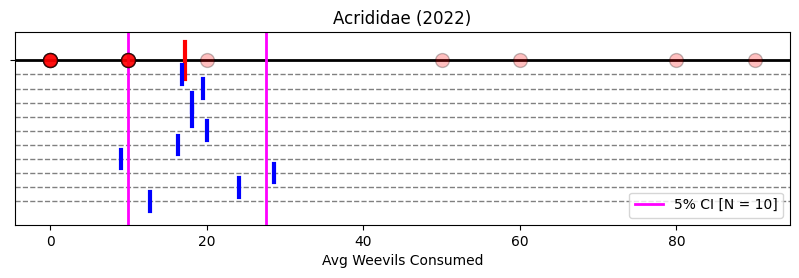

In [8]:
# No need to recompute bootstrap because we saved those samples
fig, ax = plt.subplots(figsize=(10,2.5))
ax.set_ylim(-1.75, 0.3)
ax.set_yticks([0], '')
ax.set_title(f'{family} ({year})' )
ax.set_xlabel('Avg Weevils Consumed')
ax.axhline(0, c='k', lw=2, zorder=1)
ax.plot([values.mean(), values.mean()], [0.2, -0.2], c='r', lw=3, zorder=2)
ax.scatter(values , np.zeros(len(values)), alpha=0.25, marker='o', s=100, fc='r', ec = 'k', zorder=3);

for i in range(N):
    nudge = -0.15*(i+1) # Every resample will be plotted a nudge below the previous one
    ax.axhline(nudge, c='gray', ls='dashed', lw=1, zorder=1)
    ax.plot([means[i], means[i]], [nudge+0.1, nudge-0.1], c='blue', lw=3, zorder=3)

ax.axvline(lower_ci, lw=2, c='magenta', label=f'{(1-alpha)*100:.0f}% CI [N = {len(bootstrapped_samples)}]', zorder=1)
ax.axvline(upper_ci, lw=2, c='magenta', zorder=1);
ax.legend();

Notice that the magenta bars effectively encompass most of the sampled means except one that is barely missed. Remember: 95% CI means the interval that will contain 95% of sampled means.

### 2.3 `stats.bootstrap` for large `N` values

Now, just like with standard errors, our CI estimation can improve if we sample many, many more times than a mere `N = 10`. Let's try `N = 10000`. And when it comes to large `N`s, we will use [the `stats.bootstrap` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html).

When it comes to confidence intervals, we also have to pay attention to the `method` parameter.

In [9]:
#  Declare the random number generator for reproducibility
rng = np.random.default_rng(seed = 42)

# Compute the bootstrap
# - The input data `conc` must be in a single sequence: we do that by making it part of a tuple of length 1
#   - Notice the comma INSIDE the parentheses
# - We are interested in the confidence interval of what statistic?
#   - We are interested in the CI for the mean
#   - The function to compute the mean is `np.mean`
# - Specify the number of resamples
# - Specify the confidence level for the CI
# - Specify the method to determine the CI
#   - More on this later
# - Specify the random number generator for reproducibility

N = 10000
pboot = stats.bootstrap( (values,), statistic=np.mean, n_resamples=N, confidence_level=alpha, method='percentile', rng=rng)

# `boot` contains the CI
boot_ci = pboot.confidence_interval

# print the results
# Notice they match our manual calculations
print(f'Lower {(alpha)*100:.0f}% CI value:\t {boot_ci.low:.3f} consumed weevils')
print(f'Upper {(alpha)*100:.0f}% CI value:\t {boot_ci.high:.3f} consumed weevils')

Lower 95% CI value:	 7.273 consumed weevils
Upper 95% CI value:	 29.091 consumed weevils


The above CI is determined with the `percentile` method, the same method we did manually in 2.2

While this quantile-based method is easy to compute manually, it can have serious drawbacks if the values in a sample are skewed. As a rule of thumb, it is better to determine the CI with the `BCa` method&mdash;bias-corrected and accelerated. This method produces much more accurate CI values.

In [10]:
# Recomputing the CI
# We can reuse the bootstrapped values

boot = stats.bootstrap( (values,), statistic=np.mean, n_resamples=N, confidence_level=alpha, method='BCa', 
                       rng=rng, bootstrap_result=pboot)

boot_ci = boot.confidence_interval
print(f'Lower {(alpha)*100:.0f}% CI value:\t {boot_ci.low:.3f} consumed weevils')
print(f'Upper {(alpha)*100:.0f}% CI value:\t {boot_ci.high:.3f} consumed weevils')

Lower 95% CI value:	 8.636 consumed weevils
Upper 95% CI value:	 32.273 consumed weevils


By taking 10,000 resamples, our 95% CI estimate increased, but just a bit. Repeating more times the sampling will probably not change much. After all, there is only so much bootstrapping can do when working with only four original data points.


&#9989;&nbsp; **Question 5: Without running any Python**

- Complete the phrase below

*For the **99%** confidence interval, we look at the "central `___`"&mdash;we shave the bottom and top `____`%, and keep the rest&mdash;like in the cartoon below. In other words, we look at the `___`th and `___`th *quantiles* of the `means` array.*

---

# 4. Confidence Intervals computed with the Central Limit Theorem

<img src="https://upload.wikimedia.org/wikipedia/commons/7/7b/IllustrationCentralTheorem.png" style="display:block; margin-left: auto; margin-right: auto; width: 60%" alt="Whatever the form of the population distribution, the sampling distribution tends to a Gaussian, and its dispersion is given by the Central Limit Theorem.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://commons.wikimedia.org/wiki/File:IllustrationCentralTheorem.png" target="_blank">Wikimedia</a></p>

A cornerstone from probability theory is the [Central Limit Theorem](https://en.wikipedia.org/wiki/Central_limit_theorem). It tells us that if we collect a bunch of means, these means will follow a normal curve. *Every. Single. Time*. Regardless of the experiment we are doing! And so, we don't need to bootstrap samples. We just need to compute the $\frac\alpha2$ and $1-\frac\alpha2$ quantiles of this normal curve! BAM!!

**Watch the video below to understand better what the CLT is and what it can do for you.**

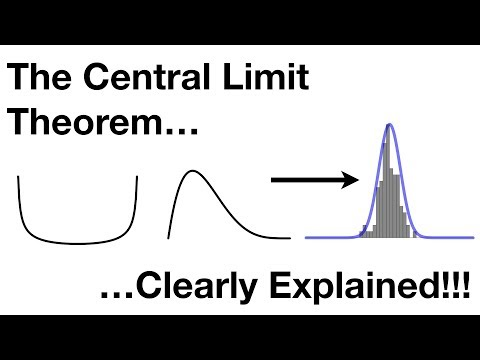

In [11]:
from IPython.display import YouTubeVideo  
YouTubeVideo("YAlJCEDH2uY",width=640,height=360)

### 4.1 The fine print and Student's $t$ to the rescue

The CLT lives in *math* world, not in *real* world. As the video above mentioned near the end, for the CLT to work in the real world, we usually need a sample size $n > 20$. However, many times, due to time/energy/money constraints, you will find yourself with less than 20 values per sample. What do you do, then?

**You use the [Student's t distribution](https://en.wikipedia.org/wiki/Student's_t-distribution) instead of the normal!**

This distribution corrects the CLT whenever you have small sample sizes. It depends on one parameter: **degrees of freedom (*df*)**, which is related to the size of your sample. 
- With small sample sizes, you have a small $df$, which will make the Student's t and the normal curves different: the CLT needs more correction.
- As your sample size increases, so does $df$, and Student's t distribution looks more and more to the normal.

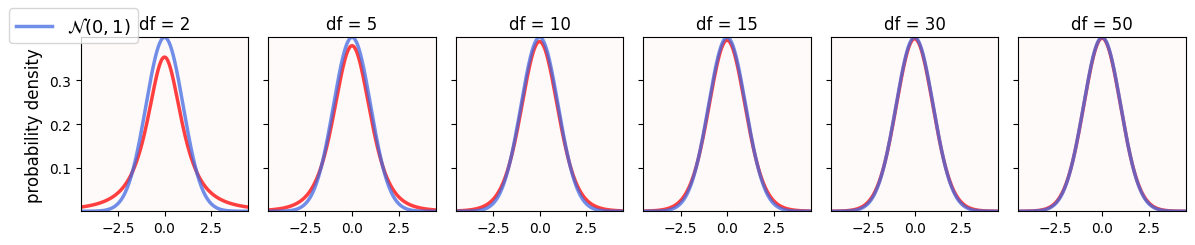

In [12]:
# In red, we plot different Student's ts for different degrees of freedom
# In blue is the standard normal distribution

dfs = [2,5,10,15,30,50]

x = np.linspace(-4.5,4.5,250)
fig, ax = plt.subplots(1,len(dfs),figsize=(12,2.5),sharex=True, sharey=True)
for i in range(len(dfs)):
    ax[i].plot(x, stats.norm.pdf(x), c='royalblue', lw=2.5, label='$\mathcal{N}(0,1)$', zorder=2, alpha=0.75)
    ax[i].plot(x, stats.t.pdf(x, dfs[i]), c='r', lw=2.5, zorder=1, alpha=0.75)
    ax[i].set_facecolor('snow')
    ax[i].set_title('df = {}'.format(dfs[i]), fontsize=12)
    ax[i].margins(0)
fig.legend(*ax[0].get_legend_handles_labels(), loc='upper left', fontsize=13)
fig.supylabel('probability density', fontsize=12)

fig.tight_layout();

&#9989;&nbsp; **Question 6**

Run the code above to compare the standard normal (blue) and Student's $t$ (red) curves for different degrees of freedom. 
- How different are these two curves for small degrees of freedom?
- What happens as the degrees of freedom increase?

<font size=+3>&#9998;</font> *Put your answers here.*

### 4.2 Just give me the formula already!

To recap:
- The CLT says that our means will be distributed as a normal curve in a perfect math world
- We use the Student's t curve instead when dealing with the real world
- We then use the t quantiles instead of bootstrapping

All in all, the confidence interval formula for a sample of size $n$ is:

$$\text{Confidence Interval (level}\;\alpha) = \text{Mean} \pm t_{(1+\alpha)/2\;,\;n-1}\times\text{Standard Error},$$
where $t_{(1+\alpha)/2\;,\;n-1}$ is the $\frac{1+\alpha}2$-th quantile of a t distribution of $n-1$ degrees of freedom.

We can get the $t$ quantiles in Python with [the `stats.t.ppf` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html). 

In [13]:
# Using Python to compute the 95% CI leveraging the CLT
# Same as before
print(f'Upper {alpha*100:.0f}% CI quantile:\t {upper_q:.3f}')

# Get the quantiles of the t curve with n-1 degrees of freedom
t = stats.t.ppf(upper_q, len(values) - 1)
print('-----')

# Compute confidence intervals
lower_ci = values.mean() - t*values.sem()
upper_ci = values.mean() + t*values.sem()

print(f'Lower {alpha*100:.0f}% CI value:\t {lower_ci:.2f} consumed weevils')
print(f'Upper {alpha*100:.0f}% CI value:\t {upper_ci:.2f} consumed weevils')

Upper 95% CI quantile:	 0.975
-----
Lower 95% CI value:	 5.33 consumed weevils
Upper 95% CI value:	 29.22 consumed weevils


Now we have `29.2` consumed rice weevils as the upper 95% CI. When doing bootstrap we obtained `32.3` weevils. 



---

## 5. A wrong formula that is common in some textbooks/worksheets

Out in the wild you might find textbooks/worksheets that state that the confidence interval formula is:

$$\text{CI}_\alpha = \text{Mean}\pm z_{(1+\alpha)/2}\times\frac{\text{Standard Deviation}}{\sqrt{\text{Sample size}}}.$$

- Remember that $\text{Standard Error} = \sigma/\sqrt N$, so there is no difference there between our previous formula and this new one.

- What it's new is the use of *normal curve* quantiles instead of t curve ones.

If we have a small sample size, like $n = 5$, the difference between normal and t quantiles can be substantial. 


### 5.1 [Time-permitting] Why normal quantiles are not good good enough?

We will not use real data for this last part. We will work instead with *simulated* (synthetic, artificial) numbers between 0 and 12 sampled from a *Gamma* distribution. This distribution has a *true* mean $\mu = 4$ and standard deviation $\sigma = 2$.

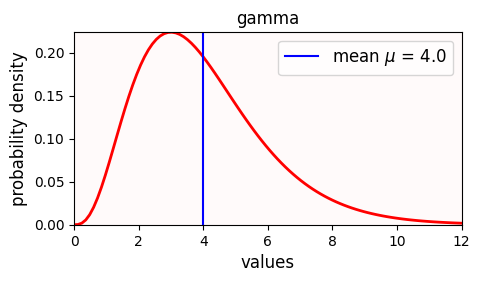

In [14]:
# Establishing our synthetic data
fs = 12 # fontsize variable for plots
xvals = np.linspace(0,12,100)

# SciPy stats come with a large number of probability distributions
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.html
gamma = stats.gamma(4, scale=1)

fig, ax = plt.subplots(figsize=(5,2.5))
ax.plot(xvals, gamma.pdf(xvals), c='r', lw=2, zorder=1)
ax.axvline(gamma.mean(), c='b', ls='solid', label=f'mean $\\mu$ = {gamma.mean():.1f}', zorder=2)

x = np.linspace(gamma.mean() - gamma.std(), gamma.mean() + gamma.std(), 50)
ax.legend(loc='upper right', fontsize=fs)
ax.set_facecolor('snow')
ax.set_title('gamma')
ax.margins(0)
ax.set_ylabel('probability density', fontsize=fs)
ax.set_xlabel('values', fontsize=fs);

Notice that the Gamma distribution the same standard deviation but it is a bit skewed to the left. 

&#9989;&nbsp; **Task 7**

Run the following simulation. 

1. Draw a sample of `n = 7` Gamma numbers
3. Compute their mean $\bar\mu$ and their SD $\bar\sigma$.
4. Use the SD to compute the 95% CI according to our (flawed) formula above
5. Check whether the confidence interval contains the actual population mean $\mu$ or not. If so, do `tally += 1`
6. Repeat steps 2&ndash;5 `N = 100` times

Intervals containing mu:	92 [92.0%]


Intervals not containing mu:	8 [8.0%]


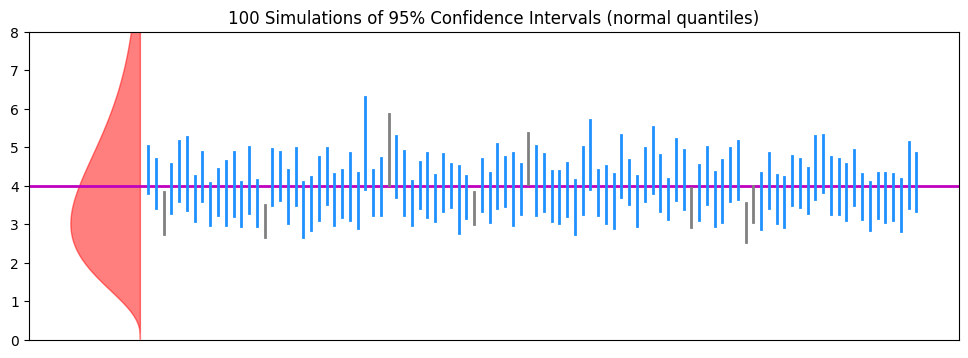

In [15]:
# Draw samples of size n and repeat N = 100 times
n = 30
N = 100

mu = gamma.mean()

# Compute the 0.975-th quantile of the NORMAL curve (which corresponds to 95% CI)
z = stats.norm.ppf(0.975)

fig, ax = plt.subplots(1,1,figsize=(12,4))

ax.fill_betweenx(xvals, -4*gamma.pdf(xvals), 0, color='r', alpha=0.5, zorder=1) # just for aesthetics

# Draw a horizontal line for the true mean
ax.axhline(mu, c='m', lw=2, zorder=2)
ax.tick_params(bottom=False, labelbottom=False)
ax.set_ylim(0 , 8)

tally = 0
for j in range(N):
    nudge = 0.1*(j+1)

    # Draw a sample of size n
    sample = gamma.rvs(n)

    # Get its sample mean and SD
    sample_mean = sample.mean()
    sample_sd = sample.std(ddof=1)

    # Use flawed CI formula with the NORMAL quantile
    ci_lower, ci_upper = (sample_mean - z*sample_sd/np.sqrt(n), sample_mean + z*sample_sd/np.sqrt(n))

    # Keep track on whether the interval contains indeed or not the population mean
    if (mu >= ci_lower) and (mu <= ci_upper):
        ax.plot([nudge, nudge], [ci_lower, ci_upper], c='dodgerblue', lw=2, zorder=3)
        tally += 1
    else:
        ax.plot([nudge, nudge], [ci_lower, ci_upper], c='gray', lw=2, zorder=3)
ax.set_title(f'{N} Simulations of 95% Confidence Intervals (normal quantiles)', fontsize=fs)
print(f'Intervals containing mu:\t{tally} [{tally/N*100:.1f}%]')
print(f'Intervals not containing mu:\t{N-tally} [{(N-tally)/N*100:.1f}%]')

&#9989;&nbsp; **Question 8** 

Remember the definition of 95% CI: By repeating our sampling `N = 100` times, we expect that 95 (&pm; change) of our CIs contain $\mu$.

- Do the confidence intervals behave as advertised?
- Is this a *consistent* behavior, ie., if you re-run the cell above&mdash;making new random numbers&mdash;do you get similar results?

*Note*: Wait at least 1 second between runs to make sure all the random numbers are new.

Intervals containing mu:	95 [95.0%]
Intervals not containing mu:	5 [5.0%]


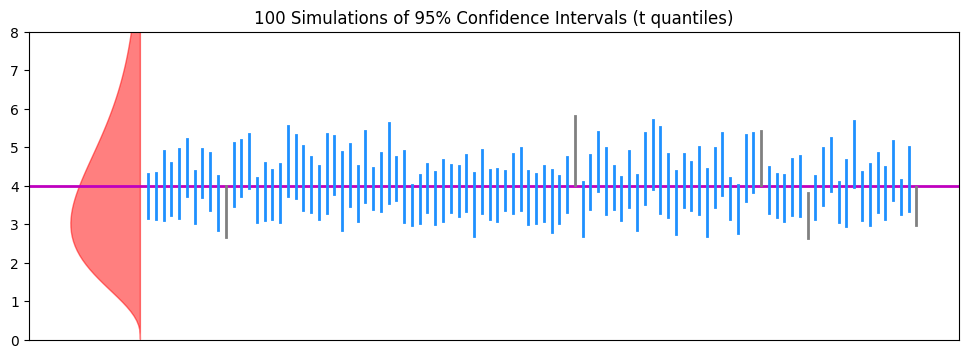

In [16]:
# Compute the 0.975-th quantile of the T curve (which corresponds to 95% CI)
t = stats.t.ppf(0.975, n-1)

fig, ax = plt.subplots(1,1,figsize=(12,4))

ax.fill_betweenx(xvals, -4*gamma.pdf(xvals), 0, color='r', alpha=0.5, zorder=1) # just for aesthetics

# Draw a horizontal line for the true mean
ax.axhline(mu, c='m', lw=2, zorder=2)
ax.tick_params(bottom=False, labelbottom=False)
ax.set_ylim(0 , 8)

tally = 0
for j in range(N):
    nudge = 0.1*(j+1)

    # Draw a sample of size n
    sample = gamma.rvs(n)

    # Get its sample mean and SD
    sample_mean = sample.mean()
    sample_sd = sample.std(ddof=1)

    # Use flawed CI formula with the T quantile
    ci_lower, ci_upper = (sample_mean - t*sample_sd/np.sqrt(n), sample_mean + t*sample_sd/np.sqrt(n))

    # Keep track on whether the interval contains indeed or not the population mean
    if (mu >= ci_lower) and (mu <= ci_upper):
        ax.plot([nudge, nudge], [ci_lower, ci_upper], c='dodgerblue', lw=2, zorder=3)
        tally += 1
    else:
        ax.plot([nudge, nudge], [ci_lower, ci_upper], c='gray', lw=2, zorder=3)
ax.set_title(f'{N} Simulations of 95% Confidence Intervals (t quantiles)', fontsize=fs)
print(f'Intervals containing mu:\t{tally} [{tally/N*100:.1f}%]')
print(f'Intervals not containing mu:\t{N-tally} [{(N-tally)/N*100:.1f}%]')

&#9989;&nbsp; **Question 9** 

- Do the 95% confidence intervals now work as advertised?

(You might still see that even with the t quantiles, the intervals fall a bit short of promises, but: are they better compared to using normal quantiles?)

<font size=+3>&#9998;</font> *Put your answer here.*

### 5.2 [Time-permitting] The importance of sample size

Going back to the CLT video, the larger our sample size, the better chances we have for the CLT to kick in. Which would mean that the formula will behave as expected.

&#9989;&nbsp; **Task 10** 

- Repeat Task 7, but this time increase the sample size. Change the top line to `n = 30`.
- How does your answers for Q8 and Q9 change?

<font size=+3>&#9998;</font> *Put your observations here.*

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri